In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier

In [2]:
sonar_data = pd.read_csv(r"sonardataset.csv")

In [3]:
sonar_data.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [4]:
sonar_data

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [5]:
sonar_data.shape

(208, 61)

In [6]:
x = sonar_data.drop(columns=["Y"]).values

y = sonar_data["Y"].values

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)  
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding: {'M': np.int64(0), 'R': np.int64(1)}


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, GridSearchCV

In [10]:
# 3-d  train/val/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

In [11]:
scaler = StandardScaler()
x_train =scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
def build_model(hidden_layers=2, neurons=64, activation="relu",
                dropout=0.2, learning_rate=1e-3):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(x_train.shape[1],)))
    model.add(Dropout(dropout))
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))

    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [13]:
keras_clf = KerasClassifier(
    model=build_model,
    epochs=150,
    verbose=0,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]
)

In [14]:
param_grid = {
    "model__activation": ["relu", "tanh"],
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128],
    "model__dropout": [0.2, 0.3],
    "model__learning_rate": [1e-3, 1e-4]
}


In [15]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=keras_clf,
                    param_grid=param_grid,
                    cv=3,
                    scoring="accuracy",
                    n_jobs=-1,
                    verbose=2)

grid.fit(x_train, y_train)

print("\n===== BEST PARAMETERS =====")
print(grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


C:\Users\VIK\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\VIK\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)



===== BEST PARAMETERS =====
{'model__activation': 'relu', 'model__dropout': 0.3, 'model__hidden_layers': 2, 'model__learning_rate': 0.001, 'model__neurons': 64}


In [16]:
best_model = grid.best_estimator_

y_pred_prob = best_model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))



Accuracy : 0.8846153846153846
Precision: 0.95
Recall   : 0.7916666666666666
F1-score : 0.8636363636363636


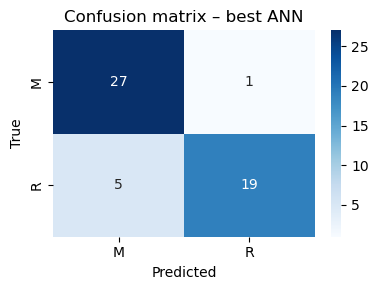

In [17]:
#  Confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion matrix – best ANN")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import accuracy_score

# Tuned model prediction
y_pred_tuned = best_model.predict(x_test)  # 0/1 class labels
acc = accuracy_score(y_test, y_pred_tuned)  # define acc


In [21]:

# 10 Quick comparison with a default & untuned model

print(" DEFAULT (untuned) MODEL ")
default_model = build_model(hidden_layers=2, neurons=64,
                            activation="relu", dropout=0.2, learning_rate=1e-3)
history = default_model.fit(x_train, y_train,
                            epochs=150,
                            batch_size=32,
                            verbose=0,
                            callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)])
y_pred_def_prob = default_model.predict(x_test, verbose=0)
y_pred_def = (y_pred_def_prob > 0.5).astype(int)

print("Default test accuracy:", accuracy_score(y_test, y_pred_def))
print("Tuned   test accuracy:", acc)
print("Improvement:", f"{acc - accuracy_score(y_test, y_pred_def):+.4f}")

 DEFAULT (untuned) MODEL 


C:\Users\VIK\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\VIK\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


Default test accuracy: 0.8461538461538461
Tuned   test accuracy: 0.8846153846153846
Improvement: +0.0385
